# W2M5. Word Cloud로 감성 데이터 시각화하기

**학습 목표**
- 레이블링된 텍스트 데이터를 시각화하는 방법을 배운다.
- 작은 데이터셋을 직접 만들어서 전체 과정을 체험해 본다.

**사전지식 (실제 Sentiment140 데이터셋 기준)**
- 실제 데이터셋은 1.6M개의 트윗으로 구성되며 결측치가 없다.
- 각 트윗은 target(0=negative, 2=neutral, 4=positive), id, date, flag, user, text 컬럼을 가진다.
- positive/negative 레이블 개수는 균형이 맞춰져 있다.

이번 미션에서는 캐글에서 실제 Sentiment140 데이터셋을 내려받은 뒤, 그중 일부만 샘플링하여 작은 데이터셋으로 사용한다.

In [9]:
import os
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import kagglehub

random.seed(42)
np.random.seed(42)

## 1. 캐글 데이터셋 다운로드 후 일부 샘플링

`kagglehub`로 [kazanova/sentiment140](https://www.kaggle.com/datasets/kazanova/sentiment140) 데이터셋을 내려받는다.

전체 1.6M개 트윗 중 positive/negative 각각 20 행만 무작위로 샘플링해서 "작은 데이터셋"으로 사용한다.

In [ ]:
# Download latest version
# 최초 1회 실행
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Path to dataset files: /Users/admin/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2


### flag (query or 'NO_QUERY')
트윗이 어떤 검색어(query)를 통해 수집됐는지를 나타내는 컬럼

In [ ]:
path = "/Users/admin/.cache/kagglehub/datasets/kazanova/sentiment140/versions/2"
csv_path = os.path.join(path, "training.1600000.processed.noemoticon.csv")

columns = ["target", "id", "date", "flag", "user", "text"]
full_df = pd.read_csv(csv_path, encoding="latin-1", names=columns)

SAMPLE_SIZE = 20  # 감성(target)별로 뽑을 샘플 개수

positive_sample_df = full_df[full_df["target"] == 4].sample(n=SAMPLE_SIZE, random_state=42)
negative_sample_df = full_df[full_df["target"] == 0].sample(n=SAMPLE_SIZE, random_state=42)

df = (
    pd.concat([positive_sample_df, negative_sample_df])
    .sample(frac=1, random_state=42) # frac: 전체 행 개수 중 몇 %(비율)를 샘플링할지를 지정하는 파라미터 (frac=1이면 전체 행의 100% 샘플링)
    .reset_index(drop=True)
)
df.head()

,target,id,date,flag,user,text
0,4,2187093130,Mon Jun 15 19:46:47 PDT 2009,NO_QUERY,KelsiBramlett,@mileycyrus i voted for you! hope you win some...
1,4,2064505980,Sun Jun 07 06:27:15 PDT 2009,NO_QUERY,LaylaNatalie,@Elijahbutterz got any pics of the whole jacket?
2,4,1882562222,Fri May 22 07:05:40 PDT 2009,NO_QUERY,jimsissy,@OnlinePublicist Thank you
3,0,2014269923,Wed Jun 03 00:59:10 PDT 2009,NO_QUERY,BlackCat_Saya,@Rohan_01 You know..it's really sad that u kno...
4,4,1793548492,Thu May 14 03:06:55 PDT 2009,NO_QUERY,_DrInE_,@sillybeggar Congrats James !! I'm sure the bo...


In [11]:
print(f"전체 트윗 수: {len(df)}")
print(df["target"].value_counts())

전체 트윗 수: 40
target
4    20
0    20
Name: count, dtype: int64


## 2. 텍스트 전처리

멘션(@user), URL, 특수문자를 제거하고 소문자로 변환한 뒤 단어 단위로 토큰화한다.

In [12]:
STOPWORDS = {"i", "im", "a", "the", "and", "so", "is", "my", "to", "we", "you",
             "this", "of", "for", "in", "on", "so", "it", "with", "again"}

def clean_and_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"http\S+|@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w and w not in STOPWORDS]
    return words

df["words"] = df["text"].apply(clean_and_tokenize)
df[["target", "text", "words"]].head()

,target,text,words
0,4,@mileycyrus i voted for you! hope you win some...,"[voted, hope, win, some, great, awards, good, ..."
1,4,@Elijahbutterz got any pics of the whole jacket?,"[got, any, pics, whole, jacket]"
2,4,@OnlinePublicist Thank you,[thank]
3,0,@Rohan_01 You know..it's really sad that u kno...,"[knowits, really, sad, that, u, know, that, ur..."
4,4,@sillybeggar Congrats James !! I'm sure the bo...,"[congrats, james, sure, book, going, be, huge,..."


## 3. Positive / Negative 단어 리스트 생성

감성별로 전처리된 단어들을 하나의 리스트로 모은다.

In [13]:
positive_words = df.loc[df["target"] == 4, "words"].explode().tolist()
negative_words = df.loc[df["target"] == 0, "words"].explode().tolist()

print(f"Positive 단어 수: {len(positive_words)}")
print(f"Negative 단어 수: {len(negative_words)}")

Positive 단어 수: 146
Negative 단어 수: 194


## 4. 샘플링을 통한 단어 선택 (최대 200개)

Word Cloud에 사용할 단어는 전체 단어 목록에서 무작위로 샘플링하여 선택한다. 단어 수가 200개보다 적으면 복원추출(replace=True)로 채운다.

In [14]:
def sample_words(words, max_words=200, seed=0):
    rng = np.random.default_rng(seed)
    replace = len(words) < max_words
    return rng.choice(words, size=max_words, replace=replace)

positive_sample = sample_words(positive_words, max_words=200, seed=42)
negative_sample = sample_words(negative_words, max_words=200, seed=43)

print(positive_sample[:20])
print(negative_sample[:20])

['jacket' 'queen' 'make' 'but' 'late' 'yes' 'whole' 'cant' 'happy'
 'jacket' 'day' 'as' 'be' 'maybe' 'guys' 'tweet' 'go' 'book' 'some' 'good']
['right' 'put' 'either' 'classmate' 'why' 'that' 'reading' 'off' 'gotta'
 'great' 'mistake' 'lunch' 'only' 'check' 'didnt' 'had' 'reading'
 'sleeping' 'computer' 'jarre']


## 5. Word Cloud 생성

샘플링된 단어들로 각각 Positive/Negative Word Cloud를 생성한다. `max_words=200`으로 표시할 단어 수를 제한한다.

In [15]:
wc_positive = WordCloud(
    width=800, height=600, background_color="white",
    max_words=200, colormap="summer", random_state=42,
).generate(" ".join(positive_sample))

wc_negative = WordCloud(
    width=800, height=600, background_color="white",
    max_words=200, colormap="autumn", random_state=42,
).generate(" ".join(negative_sample))

## 6. 시각화

두 Word Cloud를 하나의 plot(figure)에 나란히 출력한다.

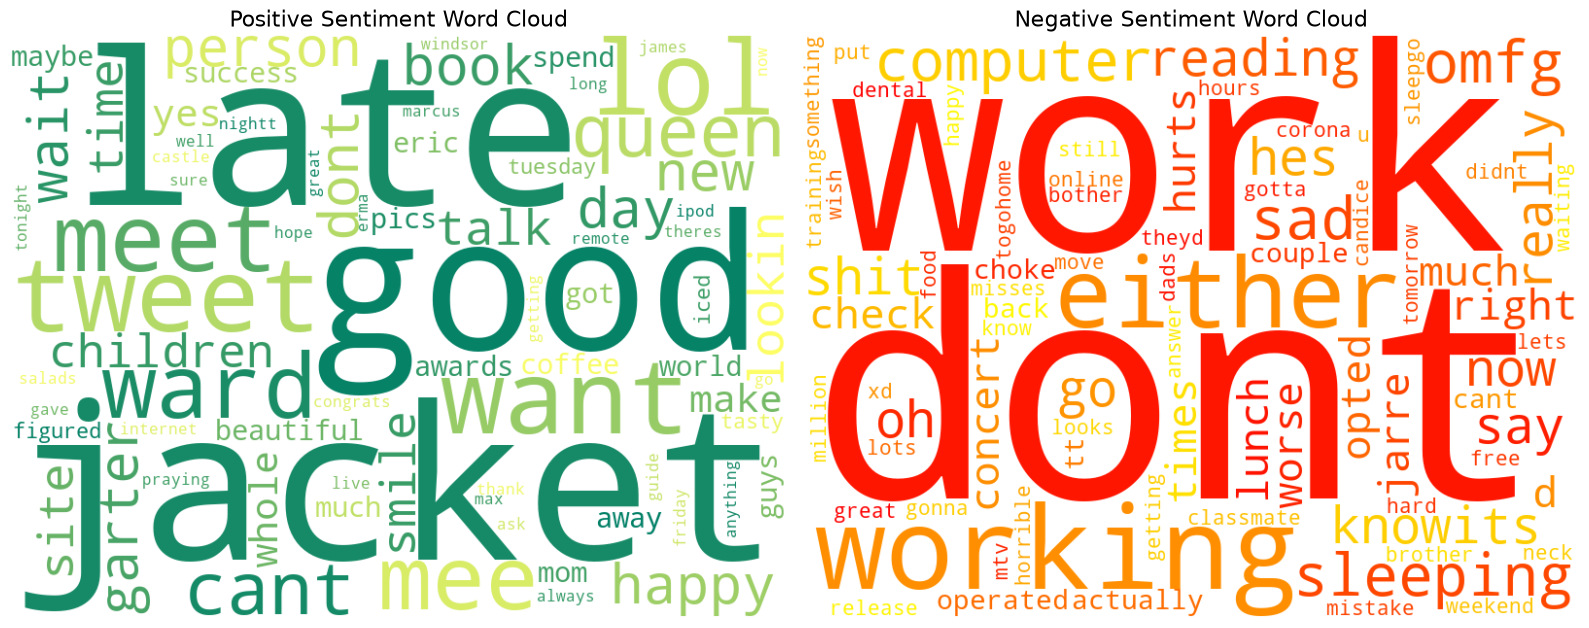

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wc_positive, interpolation="bilinear")
axes[0].set_title("Positive Sentiment Word Cloud", fontsize=16)
axes[0].axis("off")

axes[1].imshow(wc_negative, interpolation="bilinear")
axes[1].set_title("Negative Sentiment Word Cloud", fontsize=16)
axes[1].axis("off")

plt.tight_layout()
plt.show()